<a href="https://colab.research.google.com/github/Subuktageen-Farooqi/ms_course_deeplearning/blob/main/ms_deeplearning_tutorial_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [1/50] | D Loss: 0.1049 | G Loss: 5.6864
Epoch [2/50] | D Loss: 1.5540 | G Loss: 1.8995
Epoch [3/50] | D Loss: 0.5415 | G Loss: 1.9388
Epoch [4/50] | D Loss: 0.1298 | G Loss: 4.1270
Epoch [5/50] | D Loss: 0.3539 | G Loss: 4.4836
Epoch [6/50] | D Loss: 0.4474 | G Loss: 3.7246
Epoch [7/50] | D Loss: 0.7313 | G Loss: 3.6124
Epoch [8/50] | D Loss: 0.3438 | G Loss: 5.8677
Epoch [9/50] | D Loss: 0.2271 | G Loss: 5.3369
Epoch [10/50] | D Loss: 0.4994 | G Loss: 3.0940


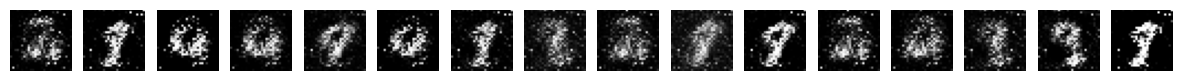

Epoch [11/50] | D Loss: 0.3220 | G Loss: 4.2120
Epoch [12/50] | D Loss: 0.2198 | G Loss: 3.9625
Epoch [13/50] | D Loss: 1.0122 | G Loss: 4.1474
Epoch [14/50] | D Loss: 0.5569 | G Loss: 1.9722
Epoch [15/50] | D Loss: 0.2947 | G Loss: 3.0000
Epoch [16/50] | D Loss: 0.7648 | G Loss: 2.6478
Epoch [17/50] | D Loss: 1.0241 | G Loss: 3.0814
Epoch [18/50] | D Loss: 0.3160 | G Loss: 3.7160
Epoch [19/50] | D Loss: 0.5120 | G Loss: 5.0662
Epoch [20/50] | D Loss: 0.4678 | G Loss: 2.6026


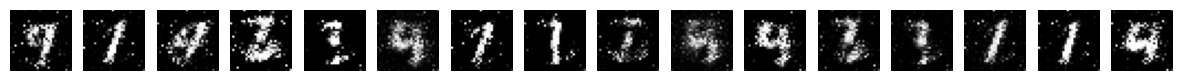

Epoch [21/50] | D Loss: 0.5111 | G Loss: 2.5370
Epoch [22/50] | D Loss: 0.5933 | G Loss: 3.0552
Epoch [23/50] | D Loss: 0.3606 | G Loss: 3.9245
Epoch [24/50] | D Loss: 0.5524 | G Loss: 2.8690
Epoch [25/50] | D Loss: 0.3954 | G Loss: 4.2919
Epoch [26/50] | D Loss: 0.4378 | G Loss: 2.5390
Epoch [27/50] | D Loss: 0.5012 | G Loss: 3.1444
Epoch [28/50] | D Loss: 0.3996 | G Loss: 1.5286
Epoch [29/50] | D Loss: 0.6857 | G Loss: 2.5572
Epoch [30/50] | D Loss: 0.6487 | G Loss: 3.1507


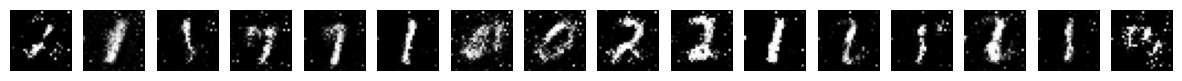

Epoch [31/50] | D Loss: 0.7133 | G Loss: 2.0590
Epoch [32/50] | D Loss: 0.7027 | G Loss: 2.1362
Epoch [33/50] | D Loss: 0.7516 | G Loss: 2.3129
Epoch [34/50] | D Loss: 0.6248 | G Loss: 2.8933
Epoch [35/50] | D Loss: 0.7735 | G Loss: 1.9765
Epoch [36/50] | D Loss: 0.9045 | G Loss: 2.3628
Epoch [37/50] | D Loss: 0.5574 | G Loss: 2.0366
Epoch [38/50] | D Loss: 0.6273 | G Loss: 2.1338
Epoch [39/50] | D Loss: 0.6595 | G Loss: 2.5911
Epoch [40/50] | D Loss: 0.8479 | G Loss: 1.7284


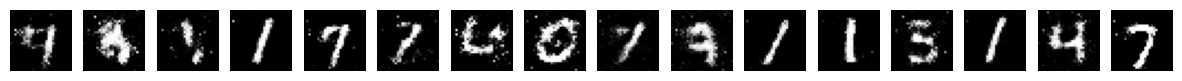

Epoch [41/50] | D Loss: 0.4486 | G Loss: 1.8433
Epoch [42/50] | D Loss: 0.8219 | G Loss: 1.3460
Epoch [43/50] | D Loss: 0.6770 | G Loss: 1.9881
Epoch [44/50] | D Loss: 0.9643 | G Loss: 2.0569
Epoch [45/50] | D Loss: 0.7620 | G Loss: 1.9053
Epoch [46/50] | D Loss: 0.5588 | G Loss: 1.8940
Epoch [47/50] | D Loss: 0.6465 | G Loss: 2.3408
Epoch [48/50] | D Loss: 0.8252 | G Loss: 1.9111
Epoch [49/50] | D Loss: 0.7788 | G Loss: 1.7596
Epoch [50/50] | D Loss: 0.5575 | G Loss: 2.1567


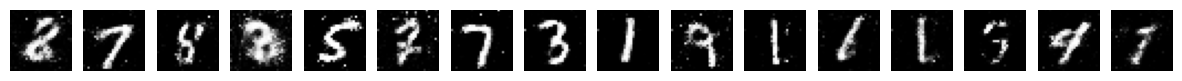

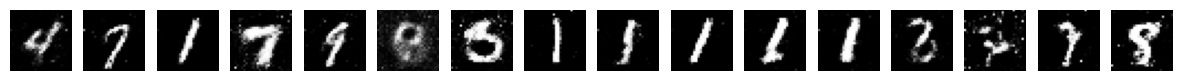

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# MNIST data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to range [-1, 1]
])

# Load dataset
batch_size = 64
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()  # Output in range [-1, 1]
        )

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

latent_dim = 100
generator = Generator(latent_dim).to("cuda" if torch.cuda.is_available() else "cpu")

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # Output probability
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the image
        return self.model(x)

discriminator = Discriminator().to("cuda" if torch.cuda.is_available() else "cpu")

# Loss function
criterion = nn.BCELoss()

# Optimizers
lr = 0.0002
generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Training loop
def train_gan(generator, discriminator, train_loader, epochs, latent_dim):
    for epoch in range(epochs):
        for real_images, _ in train_loader:
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # Labels
            real_labels = torch.ones(batch_size, 1).to(device)
            fake_labels = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            discriminator_optimizer.zero_grad()

            # Loss for real images
            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            # Generate fake images
            noise = torch.randn(batch_size, latent_dim).to(device)
            fake_images = generator(noise)

            # Loss for fake images
            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            # Total Discriminator loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # Train Generator
            generator_optimizer.zero_grad()

            # Generate fake images and calculate loss
            fake_outputs = discriminator(fake_images)
            g_loss = criterion(fake_outputs, real_labels)  # Fool the discriminator
            g_loss.backward()
            generator_optimizer.step()

        # Print losses for the current epoch
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

        # Visualize generated images
        if (epoch + 1) % 10 == 0:
            visualize_images(generator, latent_dim)

# Visualization function
def visualize_images(generator, latent_dim, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, latent_dim).to(device)
    generated_images = generator(noise).detach().cpu()

    # Plot images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()
    generator.train()

epochs = 50
train_gan(generator, discriminator, train_loader, epochs, latent_dim)

def generate_images(generator, latent_dim, num_images=16):
    generator.eval()
    noise = torch.randn(num_images, latent_dim).to(device)
    generated_images = generator(noise).detach().cpu()

    # Plot images
    fig, axes = plt.subplots(1, num_images, figsize=(15, 15))
    for i in range(num_images):
        axes[i].imshow(generated_images[i].squeeze(), cmap="gray")
        axes[i].axis("off")
    plt.show()

generate_images(generator, latent_dim)


Device: cuda
Epoch [1/10] | D Loss: 0.5798 | G Loss: 1.4397
Epoch [2/10] | D Loss: 0.1945 | G Loss: 2.3480
Epoch [3/10] | D Loss: 0.0882 | G Loss: 6.6272
Epoch [4/10] | D Loss: 0.2568 | G Loss: 6.8923
Epoch [5/10] | D Loss: 0.6161 | G Loss: 4.4278


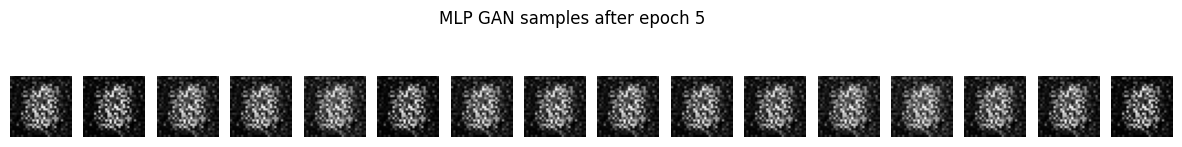

Epoch [6/10] | D Loss: 0.9229 | G Loss: 4.4231
Epoch [7/10] | D Loss: 0.9280 | G Loss: 2.3764
Epoch [8/10] | D Loss: 1.1845 | G Loss: 1.8750
Epoch [9/10] | D Loss: 0.9785 | G Loss: 1.9235
Epoch [10/10] | D Loss: 1.0264 | G Loss: 1.8915


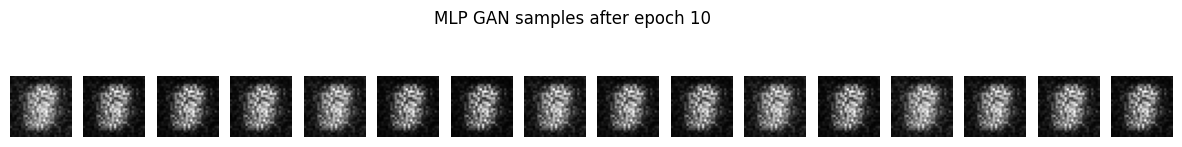

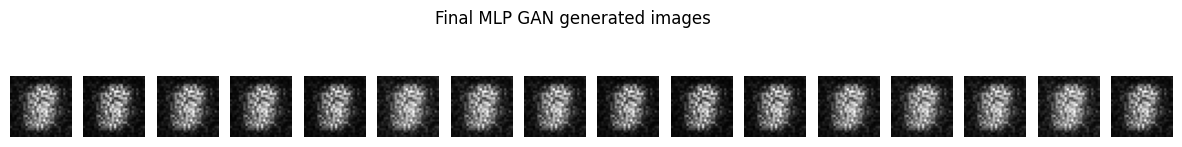

,epoch,d_loss,g_loss
0,1,0.579807,1.439732
1,2,0.194506,2.347987
2,3,0.088171,6.627245
3,4,0.256804,6.892266
4,5,0.616069,4.427806
5,6,0.922921,4.423087
6,7,0.928026,2.376375
7,8,1.184531,1.874992
8,9,0.978515,1.923523
9,10,1.026384,1.891483


In [ ]:
# PyTorch implementation of the GAN tutorial code in Cell 1.
# The screenshot code is already PyTorch, so this cell keeps the same GAN idea
# while organizing the training loop and loss tracking more cleanly.

import random
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Guardrail: keep image scale aligned with Tanh generator output.
# MNIST images are normalized to [-1, 1].
batch_size = 64
latent_dim = 100
epochs = 10      # Increase to 50 to match the PDF exactly.
lr = 0.0002

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# For faster class demonstration, set MAX_TRAIN_SAMPLES to a small number.
# Set it to None to use the full MNIST training set.
MAX_TRAIN_SAMPLES = 12000
if MAX_TRAIN_SAMPLES is not None:
    train_dataset = Subset(train_dataset, list(range(MAX_TRAIN_SAMPLES)))

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

class MLPGenerator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

class MLPDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

def show_generated_images(generator, latent_dim=100, num_images=16, title="Generated images"):
    generator.eval()

    with torch.no_grad():
        noise = torch.randn(num_images, latent_dim, device=device)
        generated_images = generator(noise).cpu()

    fig, axes = plt.subplots(1, num_images, figsize=(15, 2))
    for i in range(num_images):
        # Convert from [-1, 1] to [0, 1] for display.
        img = (generated_images[i].squeeze() + 1) / 2
        axes[i].imshow(img.clamp(0, 1), cmap="gray")
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

    generator.train()

def train_gan_basic(generator, discriminator, train_loader, latent_dim=100, epochs=10, lr=0.0002, sample_every=5):
    criterion = nn.BCELoss()
    generator_optimizer = optim.Adam(generator.parameters(), lr=lr)
    discriminator_optimizer = optim.Adam(discriminator.parameters(), lr=lr)

    history = {"epoch": [], "d_loss": [], "g_loss": []}

    for epoch in range(epochs):
        generator.train()
        discriminator.train()

        total_d_loss = 0.0
        total_g_loss = 0.0

        for real_images, _ in train_loader:
            real_images = real_images.to(device)
            current_batch_size = real_images.size(0)

            real_labels = torch.ones(current_batch_size, 1, device=device)
            fake_labels = torch.zeros(current_batch_size, 1, device=device)

            # Train discriminator
            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)

            noise = torch.randn(current_batch_size, latent_dim, device=device)
            fake_images = generator(noise)

            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)

            d_loss = real_loss + fake_loss
            d_loss.backward()
            discriminator_optimizer.step()

            # Train generator
            generator_optimizer.zero_grad()

            fake_outputs = discriminator(fake_images)
            g_loss = criterion(fake_outputs, real_labels)

            g_loss.backward()
            generator_optimizer.step()

            total_d_loss += d_loss.item()
            total_g_loss += g_loss.item()

        avg_d_loss = total_d_loss / len(train_loader)
        avg_g_loss = total_g_loss / len(train_loader)

        history["epoch"].append(epoch + 1)
        history["d_loss"].append(avg_d_loss)
        history["g_loss"].append(avg_g_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

        if (epoch + 1) % sample_every == 0:
            show_generated_images(generator, latent_dim, title=f"MLP GAN samples after epoch {epoch+1}")

    return pd.DataFrame(history)

generator_mlp = MLPGenerator(latent_dim).to(device)
discriminator_mlp = MLPDiscriminator().to(device)

history_mlp = train_gan_basic(
    generator=generator_mlp,
    discriminator=discriminator_mlp,
    train_loader=train_loader,
    latent_dim=latent_dim,
    epochs=epochs,
    lr=lr,
    sample_every=5
)

show_generated_images(generator_mlp, latent_dim, title="Final MLP GAN generated images")
history_mlp


# Task 1 — Change the Number of Epochs, Layers, and Other Settings

The PDF task asks to change the number of epochs, layers, etc.  
This cell uses a configurable MLP GAN so architecture depth and training epochs can be changed without editing the core training loop.


Epoch [1/10] | D Loss: 0.5278 | G Loss: 1.9626
Epoch [2/10] | D Loss: 0.3536 | G Loss: 7.4074
Epoch [3/10] | D Loss: 0.1734 | G Loss: 9.5185
Epoch [4/10] | D Loss: 0.6126 | G Loss: 5.5157
Epoch [5/10] | D Loss: 0.2174 | G Loss: 8.9091


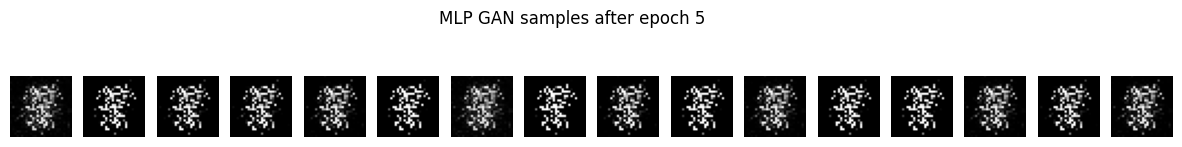

Epoch [6/10] | D Loss: 0.1776 | G Loss: 8.7496
Epoch [7/10] | D Loss: 0.5535 | G Loss: 8.4865
Epoch [8/10] | D Loss: 1.3266 | G Loss: 8.4122
Epoch [9/10] | D Loss: 0.7268 | G Loss: 5.5879
Epoch [10/10] | D Loss: 1.4277 | G Loss: 3.9063


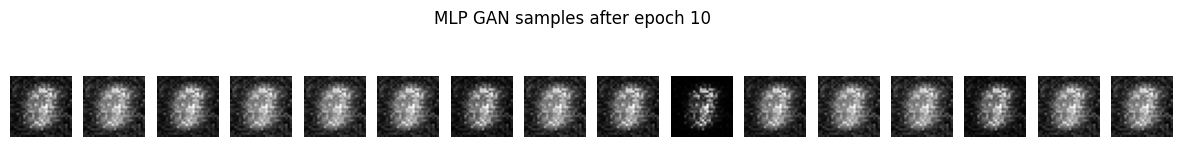

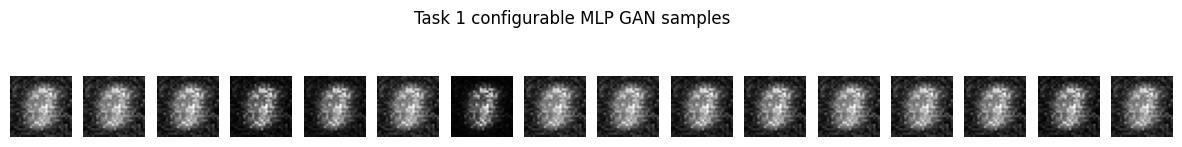

,epoch,d_loss,g_loss
0,1,0.527833,1.962618
1,2,0.353612,7.407426
2,3,0.173426,9.518512
3,4,0.612551,5.515673
4,5,0.217423,8.909082
5,6,0.177561,8.749610
6,7,0.553509,8.486512
7,8,1.326552,8.412193
8,9,0.726846,5.587872
9,10,1.427726,3.906267


In [ ]:
# Task 1: configurable MLP GAN experiment

class ConfigurableMLPGenerator(nn.Module):
    def __init__(self, latent_dim=100, hidden_dims=(128, 256, 512)):
        super().__init__()

        layers = []
        in_dim = latent_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 784))
        layers.append(nn.Tanh())

        self.model = nn.Sequential(*layers)

    def forward(self, z):
        return self.model(z).view(z.size(0), 1, 28, 28)

class ConfigurableMLPDiscriminator(nn.Module):
    def __init__(self, hidden_dims=(512, 256)):
        super().__init__()

        layers = []
        in_dim = 784

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.LeakyReLU(0.2))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, 1))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

TASK1_LATENT_DIM = 100
TASK1_EPOCHS = 10
TASK1_LR = 0.0002

# Change these lists to change the number of layers.
generator_hidden_dims = (256, 512, 1024)
discriminator_hidden_dims = (1024, 512, 256)

task1_generator = ConfigurableMLPGenerator(
    latent_dim=TASK1_LATENT_DIM,
    hidden_dims=generator_hidden_dims
).to(device)

task1_discriminator = ConfigurableMLPDiscriminator(
    hidden_dims=discriminator_hidden_dims
).to(device)

task1_history = train_gan_basic(
    generator=task1_generator,
    discriminator=task1_discriminator,
    train_loader=train_loader,
    latent_dim=TASK1_LATENT_DIM,
    epochs=TASK1_EPOCHS,
    lr=TASK1_LR,
    sample_every=5
)

show_generated_images(task1_generator, TASK1_LATENT_DIM, title="Task 1 configurable MLP GAN samples")

task1_history


# Task 2 — Replace Fully Connected Layers with Convolutional Layers

The PDF task asks to replace fully connected layers with convolutional layers for image generation.  
This cell implements a small DCGAN-style model for MNIST using `ConvTranspose2d` in the generator and `Conv2d` in the discriminator.


Epoch [1/10] | D Loss: 0.1312 | G Loss: 5.0192
Epoch [2/10] | D Loss: 0.0062 | G Loss: 6.9317
Epoch [3/10] | D Loss: 0.0136 | G Loss: 6.8356
Epoch [4/10] | D Loss: 0.0150 | G Loss: 6.7685
Epoch [5/10] | D Loss: 0.0051 | G Loss: 7.5856


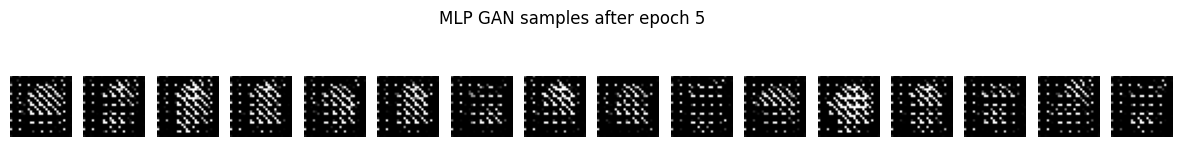

Epoch [6/10] | D Loss: 0.0011 | G Loss: 8.0304
Epoch [7/10] | D Loss: 0.0008 | G Loss: 8.2756
Epoch [8/10] | D Loss: 0.0005 | G Loss: 8.5601
Epoch [9/10] | D Loss: 0.0003 | G Loss: 8.9496
Epoch [10/10] | D Loss: 0.0003 | G Loss: 8.9034


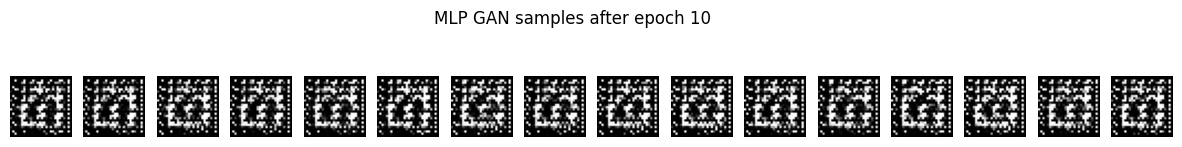

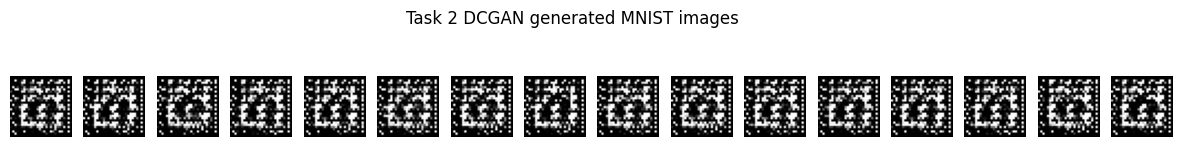

,epoch,d_loss,g_loss
0,1,0.131226,5.019188
1,2,0.006217,6.931746
2,3,0.013622,6.835582
3,4,0.014951,6.768475
4,5,0.005059,7.585613
5,6,0.001145,8.030441
6,7,0.000754,8.275624
7,8,0.000477,8.560059
8,9,0.000311,8.949617
9,10,0.000303,8.903383


In [ ]:
# Task 2: DCGAN-style convolutional GAN for MNIST

class DCGANGenerator(nn.Module):
    def __init__(self, latent_dim=100, feature_maps=64):
        super().__init__()

        self.model = nn.Sequential(
            # [B, latent_dim, 1, 1] -> [B, 256, 7, 7]
            nn.ConvTranspose2d(latent_dim, feature_maps * 4, kernel_size=7, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(feature_maps * 4),
            nn.ReLU(True),

            # [B, 256, 7, 7] -> [B, 128, 14, 14]
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.ReLU(True),

            # [B, 128, 14, 14] -> [B, 1, 28, 28]
            nn.ConvTranspose2d(feature_maps * 2, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

class DCGANDiscriminator(nn.Module):
    def __init__(self, feature_maps=64):
        super().__init__()

        self.model = nn.Sequential(
            # [B, 1, 28, 28] -> [B, 64, 14, 14]
            nn.Conv2d(1, feature_maps, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # [B, 64, 14, 14] -> [B, 128, 7, 7]
            nn.Conv2d(feature_maps, feature_maps * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(feature_maps * 2 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

TASK2_LATENT_DIM = 100
TASK2_EPOCHS = 10
TASK2_LR = 0.0002

task2_generator = DCGANGenerator(latent_dim=TASK2_LATENT_DIM, feature_maps=64).to(device)
task2_discriminator = DCGANDiscriminator(feature_maps=64).to(device)

task2_history = train_gan_basic(
    generator=task2_generator,
    discriminator=task2_discriminator,
    train_loader=train_loader,
    latent_dim=TASK2_LATENT_DIM,
    epochs=TASK2_EPOCHS,
    lr=TASK2_LR,
    sample_every=5
)

show_generated_images(task2_generator, TASK2_LATENT_DIM, title="Task 2 DCGAN generated MNIST images")

task2_history


# Task 3 — GAN for Augmented Images

The PDF task asks to develop the model for augmented images from a course study.  
Here, MNIST is augmented with random affine transforms and rotations, then the DCGAN-style model is trained on the augmented distribution.

Guardrail: only MNIST training images are used. No test set images are mixed into GAN training.


Epoch [1/10] | D Loss: 0.0783 | G Loss: 5.4980
Epoch [2/10] | D Loss: 0.0312 | G Loss: 5.8683
Epoch [3/10] | D Loss: 0.0164 | G Loss: 7.2295
Epoch [4/10] | D Loss: 0.0065 | G Loss: 7.6490
Epoch [5/10] | D Loss: 0.0014 | G Loss: 7.9125


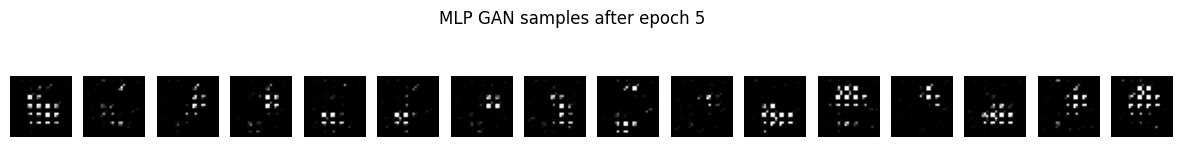

Epoch [6/10] | D Loss: 0.0061 | G Loss: 6.9475
Epoch [7/10] | D Loss: 0.0072 | G Loss: 7.3792
Epoch [8/10] | D Loss: 0.0514 | G Loss: 5.1739
Epoch [9/10] | D Loss: 0.1213 | G Loss: 4.2724
Epoch [10/10] | D Loss: 0.1597 | G Loss: 3.6846


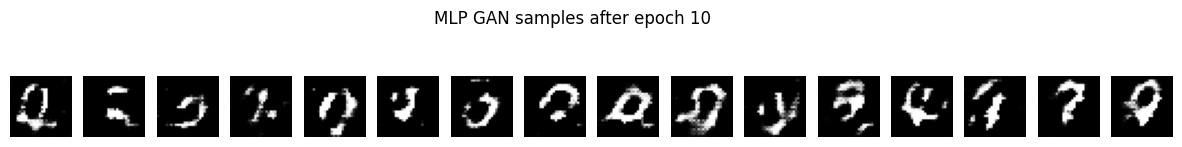

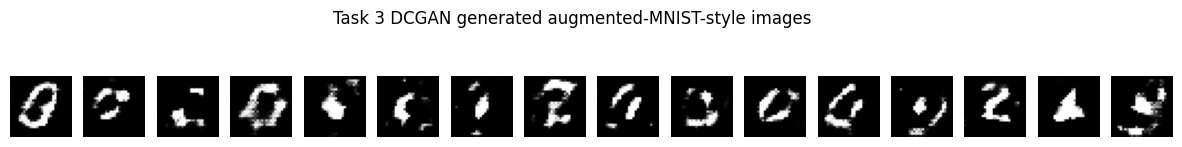

,epoch,d_loss,g_loss
0,1,0.078338,5.497996
1,2,0.031233,5.868295
2,3,0.016406,7.229493
3,4,0.006460,7.648999
4,5,0.001364,7.912468
5,6,0.006136,6.947454
6,7,0.007189,7.379180
7,8,0.051445,5.173863
8,9,0.121330,4.272436
9,10,0.159736,3.684620


In [ ]:
# Task 3: train DCGAN on augmented MNIST images

augmented_transform = transforms.Compose([
    transforms.RandomAffine(
        degrees=15,
        translate=(0.10, 0.10),
        scale=(0.90, 1.10)
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

augmented_train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=augmented_transform,
    download=True
)

# Keep runtime manageable. Set to None for full training data.
MAX_AUGMENTED_SAMPLES = 12000
if MAX_AUGMENTED_SAMPLES is not None:
    augmented_train_dataset = Subset(augmented_train_dataset, list(range(MAX_AUGMENTED_SAMPLES)))

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False
)

TASK3_LATENT_DIM = 100
TASK3_EPOCHS = 10
TASK3_LR = 0.0002

task3_generator = DCGANGenerator(latent_dim=TASK3_LATENT_DIM, feature_maps=64).to(device)
task3_discriminator = DCGANDiscriminator(feature_maps=64).to(device)

task3_history = train_gan_basic(
    generator=task3_generator,
    discriminator=task3_discriminator,
    train_loader=augmented_train_loader,
    latent_dim=TASK3_LATENT_DIM,
    epochs=TASK3_EPOCHS,
    lr=TASK3_LR,
    sample_every=5
)

show_generated_images(task3_generator, TASK3_LATENT_DIM, title="Task 3 DCGAN generated augmented-MNIST-style images")

task3_history


# Final Comparison — Loss Curves and Samples

This final cell plots the discriminator and generator losses from the main task experiments.
GAN losses are unstable by nature, so visual samples should be inspected together with loss curves.


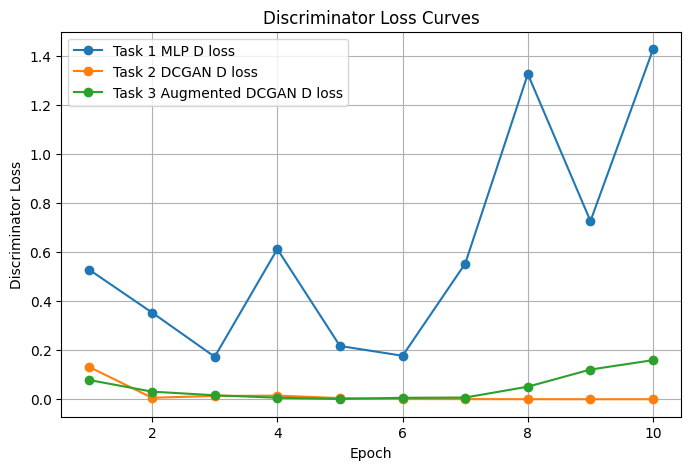

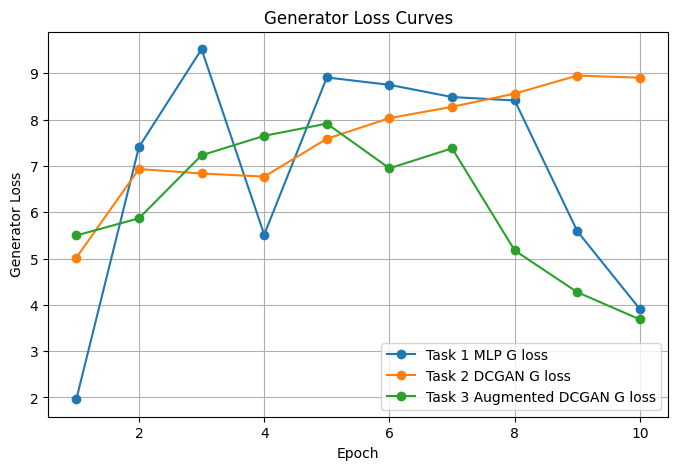

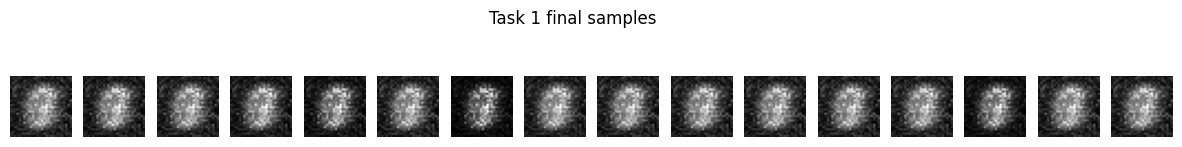

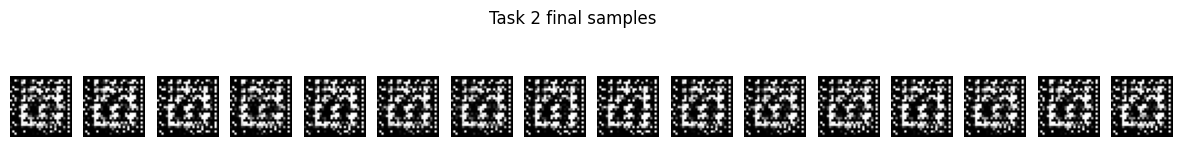

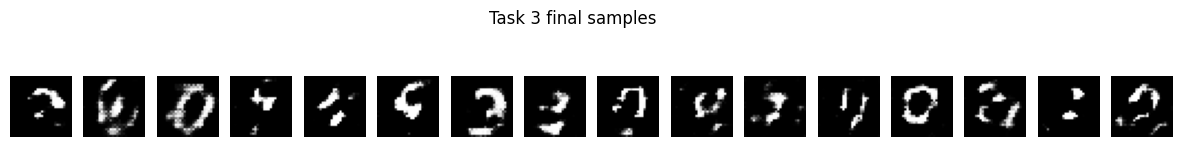

In [ ]:
# Final comparison plots

histories = {
    "Task 1 MLP": task1_history,
    "Task 2 DCGAN": task2_history,
    "Task 3 Augmented DCGAN": task3_history
}

plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    plt.plot(hist["epoch"], hist["d_loss"], marker="o", label=f"{name} D loss")
plt.xlabel("Epoch")
plt.ylabel("Discriminator Loss")
plt.title("Discriminator Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    plt.plot(hist["epoch"], hist["g_loss"], marker="o", label=f"{name} G loss")
plt.xlabel("Epoch")
plt.ylabel("Generator Loss")
plt.title("Generator Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

show_generated_images(task1_generator, TASK1_LATENT_DIM, title="Task 1 final samples")
show_generated_images(task2_generator, TASK2_LATENT_DIM, title="Task 2 final samples")
show_generated_images(task3_generator, TASK3_LATENT_DIM, title="Task 3 final samples")
